# New Section

In [4]:
!pip install kaggle

In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"projectteam00","key":"3e2290c81a5dc94cef3c455cecf846a3"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d pronaydebnath1/celeb-fbi
!unzip celeb-fbi.zip -d celeb-fbi

Streaming output truncated to the last 5000 lines.
  inflating: celeb-fbi/Celeb-FBI Dataset/3254_6.2h_82w_male_65a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/3256_5.7h_54w_female_36a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/3257_5.9h_70w_male_76a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/3259_5.8h_54w_female_48a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/325_6.5h_111w_male_34a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/3260_5.6h_47w_female_43a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/3261_5.7h_51w_female_48a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/3262_6.7h_100w_male_35a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/3263_6.1h_78w_male_56a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/3264_5.6h_56w_female_42a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/3265_5.7h_63w_female_42a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/3266_5.8h_65w_male_38a.png  
  inflating: celeb-fbi/Celeb-FBI Dataset/3267_6.1h_95w_male_38a.png  
  inflating: celeb-fbi/Cel

In [8]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [9]:
image_dir = "/content/celeb-fbi/Celeb-FBI Dataset"
images = []
labels = []

In [10]:
def clean_gender(gender):
    gender = gender.lower()
    corrections = {
        'femlale': 'female',
        'Female': 'female',
        'female': 'female',
        'male': 'male',
        'Male': 'male',
    }
    return corrections.get(gender, gender)

In [11]:

def bin_age(age):
    age = int(age)
    if age < 20:
        return 'young'
    elif age < 50:
        return 'adult'
    else:
        return 'old'

def bin_height(height):
    h = float(height)
    if h < 5.0:
        return 'short'
    elif h < 5.8:
        return 'average'
    else:
        return 'tall'

def bin_weight(weight):
    w = int(weight)
    if w < 50:
        return 'underweight'
    elif w < 100:
        return 'normal'
    else:
        return 'overweight'

In [12]:
# ======= preprocessing =======
images = []
labels = []
for filename in os.listdir(image_dir):
    if filename.endswith((".jpg", ".png")):
        img_path = os.path.join(image_dir, filename)
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (150, 150))

            parts = filename.split('_')


            if len(parts) >= 5:
                height = parts[1].replace('h', '')
                weight = parts[2].replace('w', '')
                gender = clean_gender(parts[3])

                age = parts[4].replace('a', '')
                age = age.replace('a.png', '')
                age = age.replace('a.jpg', '')
                age = age.replace('.png', '')
                age = age.replace('.jpg', '')


                try:
                    bin_age(age)
                    bin_height(height)
                    bin_weight(weight)

                    images.append(img)
                    labels.append([
                        bin_age(age),
                        bin_height(height),
                        bin_weight(weight),
                        gender
                    ])
                except ValueError:
                    print(f"Drop: {filename} invalid values ​​for age, height or weight.")

            else:
                print(f"Drop: {filename} incorrect formatting.")

        except Exception as e:
            print(f"Drop: {filename} error. {e}")

print("sample format", labels[:5])

Drop: 2728_5.7h_5.3w_female_62a.png invalid values ​​for age, height or weight.
Drop: 2009_6h_79.4w_male_37a.jpg invalid values ​​for age, height or weight.
Drop: 1036_6.1 0h_114w_male_34a.png invalid values ​​for age, height or weight.
Drop: 2483_6.1 0h_111w_male_35a.jpg invalid values ​​for age, height or weight.
Drop: 306_6.1 0h_108w_male_38a.png invalid values ​​for age, height or weight.
Drop: 470_6.1 0h_115w_male_30a.png invalid values ​​for age, height or weight.
Drop: 423_6.1 0h_104w_male_44a.png invalid values ​​for age, height or weight.
Drop: 1946_5.5h_54.5w_female_44a.png invalid values ​​for age, height or weight.
Drop: 279_5.11h_54w_female_a.png invalid values ​​for age, height or weight.
sample format [['old', 'tall', 'normal', 'male'], ['old', 'tall', 'normal', 'male'], ['old', 'tall', 'normal', 'female'], ['adult', 'average', 'normal', 'female'], ['adult', 'tall', 'normal', 'male']]


In [13]:
hog_features = [hog(img, pixels_per_cell=(12,12), cells_per_block=(2, 2)) for img in images]
hog_features = np.array(hog_features)


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(hog_features)

In [15]:
targets = {
    'age':     [row[0] for row in labels],
    'height':  [row[1] for row in labels],
    'weight':  [row[2] for row in labels],
    'gender':  [row[3].capitalize() for row in labels],
}

In [16]:
#======= Test before LDA =======
accuracy_before_lda = {}  #
for key, y in targets.items():
    print(f"\n=== {key.upper()} ===")

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    model = SVC(kernel='rbf')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_before_lda[key] = acc
    print(f"ACCURACY BEFORE LDA: {acc * 100:.2f}%")



=== AGE ===
ACCURACY BEFORE LDA: 79.25%

=== HEIGHT ===
ACCURACY BEFORE LDA: 61.55%

=== WEIGHT ===
ACCURACY BEFORE LDA: 77.17%

=== GENDER ===
ACCURACY BEFORE LDA: 86.54%


In [17]:
# ======= Test after LDA =======
accuracy_after_lda = {}
for key, y in targets.items():
    print(f"\n=== {key.upper()} ===")

    if len(set(y)) > 1:
        try:
            lda = LDA(n_components=min(len(set(y)) - 1, X_scaled.shape[1]))
            X_lda = lda.fit_transform(X_scaled, y)

            X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
                X_lda, y, test_size=0.2, random_state=42)

            model_lda = SVC(kernel='rbf')
            model_lda.fit(X_train_lda, y_train_lda)
            y_pred_lda = model_lda.predict(X_test_lda)
            acc_lda = accuracy_score(y_test_lda, y_pred_lda)

            accuracy_after_lda[key] = acc_lda
            print(f"ACCURACY AFTER LDA: {acc_lda * 100:.2f}%")

        except Exception as e:
            print(f"Can not applay LDA {key} the reason: {e}")
            accuracy_after_lda[key] = None
    else:
        print(f"Can not applay LDA {key} Because the number of items is less than 2")
        accuracy_after_lda[key] = None


=== AGE ===
ACCURACY AFTER LDA: 95.49%

=== HEIGHT ===
ACCURACY AFTER LDA: 92.44%

=== WEIGHT ===
ACCURACY AFTER LDA: 96.95%

=== GENDER ===
ACCURACY AFTER LDA: 98.82%


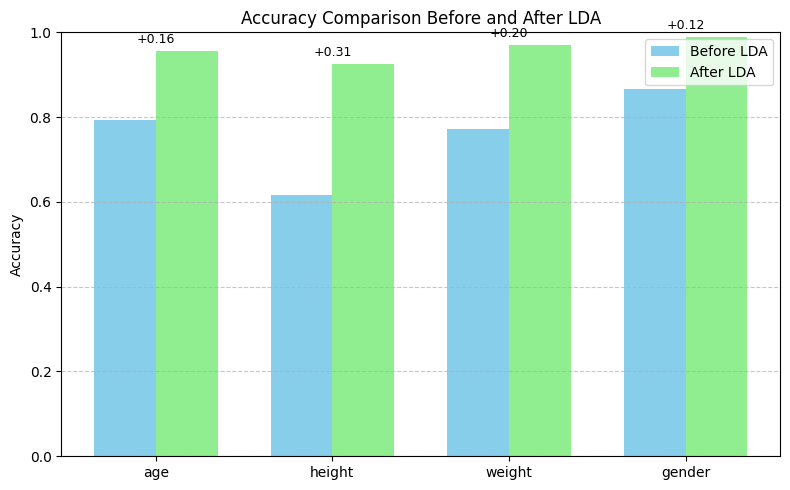

In [18]:
accuracy_before = accuracy_before_lda
accuracy_after = accuracy_after_lda

# ======= Graph =======
labels = list(accuracy_before.keys())
before_values = [accuracy_before[label] for label in labels]
after_values = [accuracy_after[label] if accuracy_after[label] is not None else 0 for label in labels]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], before_values, width=width, label='Before LDA', color='skyblue')
plt.bar([i + width/2 for i in x], after_values, width=width, label='After LDA', color='lightgreen')

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison Before and After LDA')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in x:
    if accuracy_after[labels[i]] is not None:
        diff = after_values[i] - before_values[i]
        plt.text(i, max(before_values[i], after_values[i]) + 0.02, f"+{diff:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


Saving WhatsApp Image 2025-04-26 at 23.11.11_97e7ac6d.jpg to WhatsApp Image 2025-04-26 at 23.11.11_97e7ac6d (2).jpg


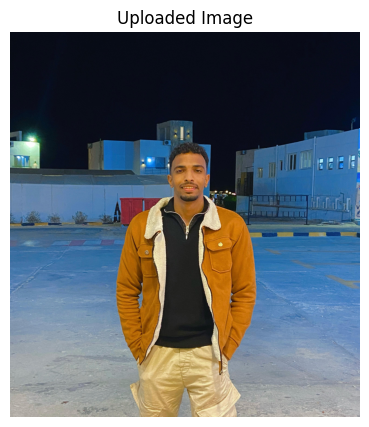


Predict image properties before LDA:
Age: adult
Height: tall
Weight: normal
Gender: Male

Predict image properties after LDA:
Age: adult
Height: tall
Weight: normal
Gender: Male


In [19]:
# رفع الصورة
uploaded = files.upload()

for filename in uploaded:
    img_path = filename
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title('Uploaded Image')
    plt.show()

    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.resize(img_gray, (150, 150))

    hog_feature = hog(img_gray, pixels_per_cell=(12, 12), cells_per_block=(2, 2)).reshape(1, -1)
    hog_scaled = scaler.transform(hog_feature)

    print("\nPredict image properties before LDA:")
    for key, y in targets.items():
        if len(set(y)) > 1:
            try:
                model = SVC(kernel='rbf')
                model.fit(X_scaled, y)
                prediction = model.predict(hog_scaled)[0]
                print(f"{key.capitalize()}: {prediction}")
            except Exception as e:
                print(f"failed {key} the reason: {e}")
        else:
            print(f"{key.capitalize()}: Not enough classes for prediction.")

    print("\nPredict image properties after LDA:")
    for key, y in targets.items():
        if len(set(y)) > 1:
            try:
                lda = LDA(n_components=min(len(set(y)) - 1, hog_scaled.shape[1]))
                X_lda = lda.fit_transform(X_scaled, y)
                model = SVC(kernel='rbf')
                model.fit(X_lda, y)

                hog_lda = lda.transform(hog_scaled)

                prediction = model.predict(hog_lda)[0]
                print(f"{key.capitalize()}: {prediction}")
            except Exception as e:
                print(f"failed {key} the reason: {e}")
        else:
            print(f"{key.capitalize()}: LDA cannot be applied because the number of items is small.")